numpy: 2.2.6
pandas: 2.3.3
matplotlib: 3.10.7
tensorflow: 2.20.0
vector -> shape: (4,), rank: 1, size: 4
scalar -> shape: (), rank: 0, size: 1
matrix -> shape: (2, 3), rank: 2, size: 6
tensor -> shape: (2, 2, 2), rank: 3, size: 8
a shape: (5, 300) b shape: (5, 300)
matmul_result shape: (5, 5)
dot_per_row shape: (5,) dot_sum (scalar): 377.02136
img shape: (224, 224, 3)
min: 3.5762787e-07 max: 0.99999416
img4d shape: (1, 224, 224, 3)
squeezed shape: (224, 224, 3)
vector v: [ 0.1 -2.5  3.6  3.6  1.2  0.   9.9  9.9  1.5 -0.2]
index of max value: 6 max value: 9.9
one-hot vector (index 6):
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
GPUs found: []
Збережено: d:\PROGA3KURS\M3kurs\DataScienceLabs\Lab6\regression.csv d:\PROGA3KURS\M3kurs\DataScienceLabs\Lab6\classification.csv


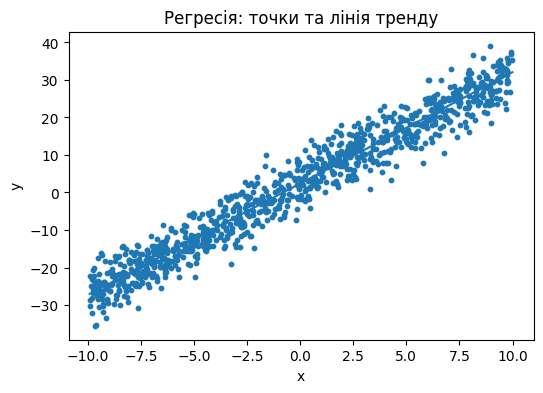

Лінія тренду: y = 2.969x + 2.390


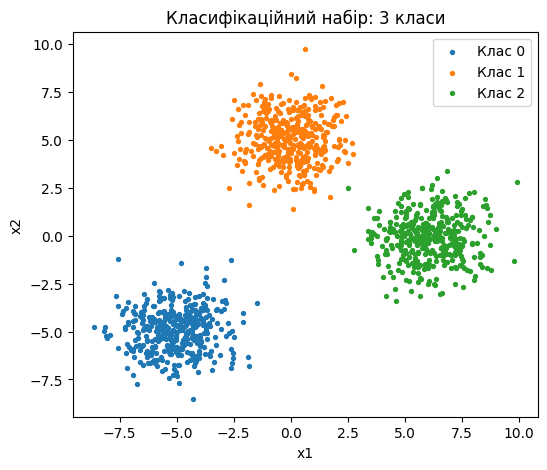

"\nfrom tensorflow.keras import layers, models\nmodel = models.Sequential([layers.Input(shape=(1,)), layers.Dense(16, activation='relu'), layers.Dense(1)])\nmodel.compile(optimizer='adam', loss='mse')\nprint(model.summary())\n# model.fit(reg[['x']].values, reg['y'].values, epochs=10, batch_size=32, validation_split=0.2)\n"

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    TF_AVAILABLE = True
except Exception as e:
    print("TensorFlow не знайдено або не імпортовано:", e)
    TF_AVAILABLE = False

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
if TF_AVAILABLE:
    print("tensorflow:", tf.__version__)
else:
    print("Щоб встановити TensorFlow (локально), виконай: pip install tensorflow")


# %% [markdown]
# Кроки 1–2: Створення тензорів (vector, scalar, matrix, tensor) та виведення форми, рангу і розміру

# %%
if TF_AVAILABLE:
    # 1. Створюємо вектор, скаляр, матрицю та тензор через tf.constant()
    vector = tf.constant([1.0, 2.0, 3.0, 4.0], dtype=tf.float32)
    scalar = tf.constant(7.5, dtype=tf.float32)
    matrix = tf.constant([[1,2,3],[4,5,6]], dtype=tf.float32)
    tensor = tf.constant([[[1,2],[3,4]], [[5,6],[7,8]]], dtype=tf.float32)

    # 2. Форма, ранг, розмір
    def inspect(t, name):
        print(f"{name} -> shape: {t.shape}, rank: {tf.rank(t).numpy()}, size: {tf.size(t).numpy()}")

    inspect(vector, 'vector')
    inspect(scalar, 'scalar')
    inspect(matrix, 'matrix')
    inspect(tensor, 'tensor')
else:
    print("TensorFlow відсутній — клітини з tf пропущені. Встанови tensorflow, щоб виконати тензорні операції.")

# %% [markdown]
# Кроки 3–5: Два тензори випадкових значень форми [5, 300], множення матриць та скалярний добуток

# %%
if TF_AVAILABLE:
    # 3. Два тензори випадкових значень між 0 та 1 форми [5,300]
    a = tf.random.uniform([5,300], minval=0., maxval=1., dtype=tf.float32, seed=42)
    b = tf.random.uniform([5,300], minval=0., maxval=1., dtype=tf.float32, seed=7)

    print('a shape:', a.shape, 'b shape:', b.shape)

    # 4. Множення матриць - a @ b^T -> [5,5]
    matmul_result = tf.matmul(a, b, transpose_b=True)
    print('matmul_result shape:', matmul_result.shape)

    # 5. Скалярний (dot) добуток: елемент-до-елемента + редукція
    elementwise = tf.multiply(a, b)  # shape [5,300]
    dot_per_row = tf.reduce_sum(elementwise, axis=1)  # вектор[5]
    dot_sum = tf.reduce_sum(dot_per_row)  # скаляр
    print('dot_per_row shape:', dot_per_row.shape, 'dot_sum (scalar):', dot_sum.numpy())
else:
    print("TensorFlow відсутній — пропускаємо кроки 3–5.")

# %% [markdown]
# Кроки 6–8: Тензор форми [224,224,3], мін/макс, reshape (squeeze)

# %%
if TF_AVAILABLE:
    # 6. Тензор [224,224,3]
    img = tf.random.uniform([224,224,3], minval=0., maxval=1., dtype=tf.float32)
    print('img shape:', img.shape)

    # 7. Мін/макс
    print('min:', tf.reduce_min(img).numpy(), 'max:', tf.reduce_max(img).numpy())

    # 8. Тензор [1,224,224,3] -> squeeze -> [224,224,3]
    img4d = tf.random.uniform([1,224,224,3], minval=0., maxval=1., dtype=tf.float32)
    print('img4d shape:', img4d.shape)
    img_squeezed = tf.squeeze(img4d, axis=0)
    print('squeezed shape:', img_squeezed.shape)
else:
    print("TensorFlow відсутній — пропускаємо кроки 6–8.")

# %% [markdown]
# Кроки 9–10: Вектор форми [10] — індекс максимуму та one-hot кодування

# %%
if TF_AVAILABLE:
    v = tf.constant([0.1, -2.5, 3.6, 3.6, 1.2, 0.0, 9.9, 9.9, 1.5, -0.2], dtype=tf.float32)
    max_index = tf.argmax(v).numpy()
    print('vector v:', v.numpy())
    print('index of max value:', max_index, 'max value:', v.numpy()[max_index])

    one_hot = tf.one_hot(max_index, depth=10)
    print('one-hot vector (index {}):'.format(max_index))
    print(one_hot.numpy())
else:
    print("TensorFlow відсутній — пропускаємо кроки 9–10.")

# %% [markdown]
# Перевірка доступу GPU

# %%
if TF_AVAILABLE:
    gpus = tf.config.list_physical_devices('GPU')
    print('GPUs found:', gpus)
    if gpus:
        try:
            tf.config.experimental.set_memory_growth(gpus[0], True)
            print('Memory growth set for GPU 0')
        except Exception as e:
            print('Could not set memory growth:', e)
else:
    print("TensorFlow відсутній — неможливо перевірити GPU.")

# %% [markdown]
# Генерація наборів даних (регресія, класифікація) і збереження у CSV

# %%
# Створимо папку data в робочій папці (якщо потрібно змінити шлях — вкажи свій)
out_dir = os.getcwd()
reg_path = os.path.join(out_dir, "regression.csv")
cls_path = os.path.join(out_dir, "classification.csv")

rng = np.random.RandomState(42)
# Регресія: y = 3x + 2 + noise
X_reg = rng.uniform(-10, 10, size=(1000,1))
y_reg = 3*X_reg[:,0] + 2 + rng.normal(scale=4.0, size=(1000,))
reg_df = pd.DataFrame({"x": X_reg[:,0], "y": y_reg})
reg_df.to_csv(reg_path, index=False)

# Класифікація: 3-класові "blobs"
centers = np.array([[ -5, -5],[0,5],[6,0]])
n_per = 400
X_cls = np.vstack([rng.normal(loc=c, scale=1.2, size=(n_per,2)) for c in centers])
y_cls = np.hstack([[i]*n_per for i in range(len(centers))])
cls_df = pd.DataFrame(np.hstack([X_cls, y_cls.reshape(-1,1)]), columns=["x1","x2","label"])
cls_df.to_csv(cls_path, index=False)

print("Збережено:", reg_path, cls_path)

# %% [markdown]
# Зчитування та графічний аналіз: регресія

# %%
reg = pd.read_csv(reg_path)
x = reg['x'].values
y = reg['y'].values

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=10)
coef = np.polyfit(x, y, deg=1)
plt.plot(np.sort(x), np.polyval(coef, np.sort(x)))
plt.title('Регресія: точки та лінія тренду')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

print('Лінія тренду: y = {:.3f}x + {:.3f}'.format(coef[0], coef[1]))

# %% [markdown]
# Графічний аналіз: класифікація

# %%
cls = pd.read_csv(cls_path)
plt.figure(figsize=(6,5))
for lab in sorted(cls['label'].unique()):
    sub = cls[cls['label']==lab]
    plt.scatter(sub['x1'], sub['x2'], s=8, label=f'Клас {int(lab)}')
plt.legend()
plt.title('Класифікаційний набір: 3 класи')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# %% [markdown]
# Приклад простої моделі (коротко) — необов'язково до запуску
# Якщо потрібно — розкоментуй блок нижче, щоб тренувати модель регресії.

# %%
"""
from tensorflow.keras import layers, models
model = models.Sequential([layers.Input(shape=(1,)), layers.Dense(16, activation='relu'), layers.Dense(1)])
model.compile(optimizer='adam', loss='mse')
print(model.summary())
# model.fit(reg[['x']].values, reg['y'].values, epochs=10, batch_size=32, validation_split=0.2)
"""

# %% [markdown]
# Поради для розгортання в Visual Studio (Jupyter Notebook)
# 1. Відкрий Visual Studio -> File -> Open -> Folder, вибери папку Lab6.
# 2. Створи virtualenv: python -m venv .venv  -> activate -> pip install -r requirements.txt
# 3. Відкрий Lab6.ipynb у Visual Studio і запусти клітини.
# 4. Для GitHub: додай Lab6 (файли .ipynb, csv, requirements.txt), commit і push (приклад команд далі).
